## Safe token management
Use local `.env` file for safe token storage

In [2]:
!pip install python-dotenv

  Using cached python_dotenv-1.1.0-py3-none-any.whl.metadata (24 kB)
Using cached python_dotenv-1.1.0-py3-none-any.whl (20 kB)


In [3]:
%load_ext dotenv
%dotenv

## Simple access example

In [4]:
import os
from qiskit import transpile
from qiskit.circuit.random import random_circuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.visualization import plot_histogram

In [5]:
token = os.environ["IBMQ_TOKEN"]

In [6]:
service = QiskitRuntimeService(
                token=token,
                channel="ibm_quantum",
            )
backend = service.least_busy(operational=True, simulator=False)

In [7]:
backend

<IBMBackend('ibm_sherbrooke')>

In [8]:
qx = random_circuit(5, depth=2)
qx.measure_all()

In [9]:
qx.draw()

┌──────┐      ┌───┐      ░ ┌─┐            
   q_0: ──────┤1     ├──────┤ Y ├──────░─┤M├────────────
              │  Dcx │      └─┬─┘      ░ └╥┘┌─┐         
   q_1: ──────┤0     ├────────┼────■───░──╫─┤M├─────────
           ┌──┴──────┴──┐     │    │   ░  ║ └╥┘┌─┐      
   q_2: ───┤ U1(3.3027) ├─────■────┼───░──╫──╫─┤M├──────
           └───┬───┬────┘        ┌─┴─┐ ░  ║  ║ └╥┘┌─┐   
   q_3: ───────┤ H ├─────────────┤ X ├─░──╫──╫──╫─┤M├───
        ┌──────┴───┴───────┐     └─┬─┘ ░  ║  ║  ║ └╥┘┌─┐
   q_4: ┤ R(2.4955,3.9219) ├───────■───░──╫──╫──╫──╫─┤M├
        └──────────────────┘           ░  ║  ║  ║  ║ └╥┘
meas: 5/══════════════════════════════════╩══╩══╩══╩══╩═
                                          0  1  2  3  4

In [10]:
transpiled = transpile(qx, backend=backend)

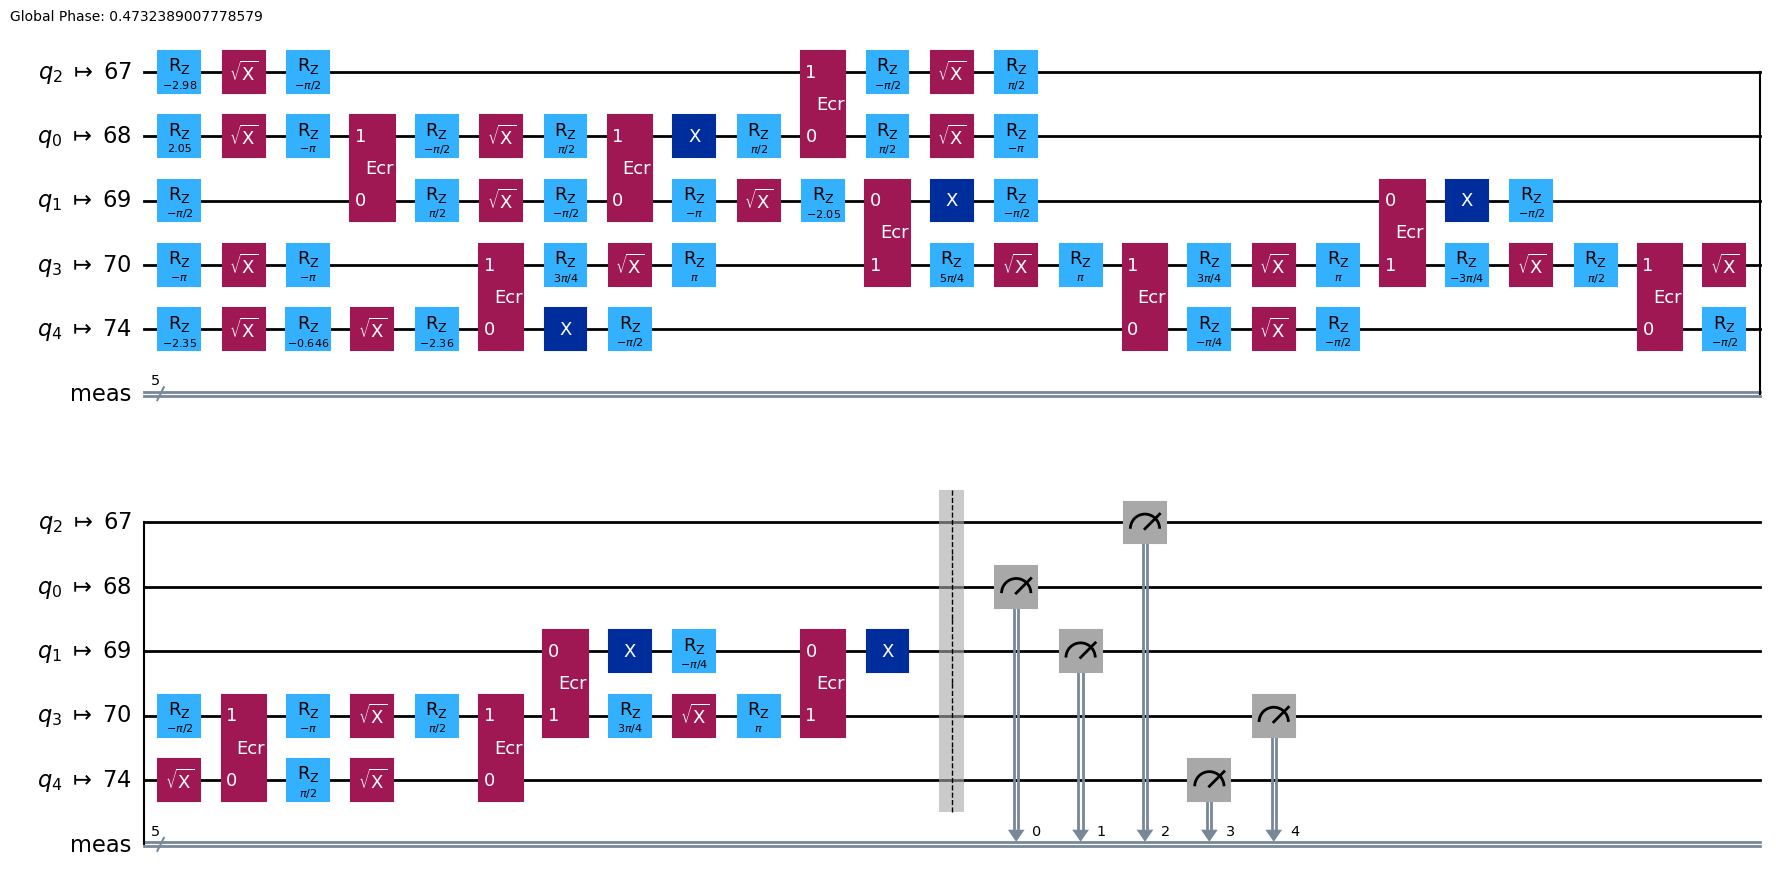

In [11]:
transpiled.draw(output="mpl")

In [12]:
sampler = SamplerV2(backend)
job = sampler.run([transpiled])
result = job.result()

In [13]:
result = job.result()

In [16]:
status = backend.status()

In [17]:
status.operational

True

In [18]:
status.pending_jobs

5

In [19]:
print(result)

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=5>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-04-05 11:26:31', stop='2025-04-05 11:26:33', size=4096>)])}, 'version': 2})


In [ ]:
job.status()

In [20]:
pub_result = result[0].data.meas.get_counts()

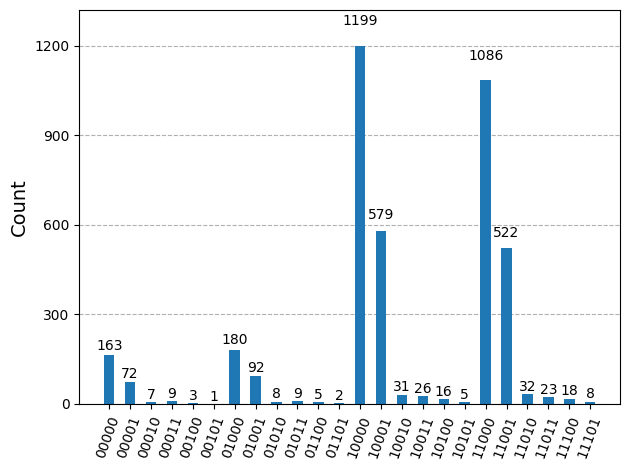

In [21]:
plot_histogram(pub_result)

## Circuit with named registers

In [7]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

qr = QuantumRegister(3, 'q')
anc = QuantumRegister(1, 'ancilla')
cr = ClassicalRegister(3, 'c')
qc = QuantumCircuit(qr, anc, cr)

qc.x(anc[0])
qc.h(anc[0])
qc.h(qr[0:3])
qc.cx(qr[0:3], anc[0])
qc.h(qr[0:3])
qc.barrier(qr)
qc.measure(qr, cr)# |1> -> |0> - |1>

qc.draw()

┌───┐          ┌───┐           ░ ┌─┐      
    q_0: ┤ H ├───────■──┤ H ├───────────░─┤M├──────
         ├───┤       │  └───┘┌───┐      ░ └╥┘┌─┐   
    q_1: ┤ H ├───────┼────■──┤ H ├──────░──╫─┤M├───
         ├───┤       │    │  └───┘┌───┐ ░  ║ └╥┘┌─┐
    q_2: ┤ H ├───────┼────┼────■──┤ H ├─░──╫──╫─┤M├
         ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐└───┘ ░  ║  ║ └╥┘
ancilla: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─────────╫──╫──╫─
         └───┘└───┘└───┘└───┘└───┘         ║  ║  ║ 
    c: 3/══════════════════════════════════╩══╩══╩═
                                           0  1  2

In [ ]:
backend = service.least_busy(operational=True, simulator=False)

In [9]:
transpiled_qc = transpile(qc, backend=backend)
transpiled_qc.draw()

global phase: π/4
                 ┌─────────┐┌────┐                                           »
      q_1 -> 110 ┤ Rz(π/2) ├┤ √X ├───────────────────────────────────────────»
                 ├─────────┤├────┤                                           »
      q_2 -> 117 ┤ Rz(π/2) ├┤ √X ├───────────────────────────────────────────»
                 └──┬───┬──┘└────┘                                   ┌──────┐»
ancilla_0 -> 118 ───┤ X ├────────────────────────────────────────────┤0     ├»
                 ┌──┴───┴──┐┌────┐┌───────────────┐┌────┐┌──────────┐│  Ecr │»
      q_0 -> 119 ┤ Rz(π/2) ├┤ √X ├┤ Rz(-0.010983) ├┤ √X ├┤ Rz(-π/2) ├┤1     ├»
                 └─────────┘└────┘└───────────────┘└────┘└──────────┘└──────┘»
            c: 3/════════════════════════════════════════════════════════════»
                                                                             »
«                                                 ┌──────┐┌─────────┐ ┌────┐»
«      q_1 -> 110 ────────────────────────────────┤0     ├┤ Rz(π/2) ├─┤ √X ├»
«                                                 │      │└─────────┘ └────┘»
«      q_2 -> 117 ────────────────────────────────┤  Ecr ├──────────────────»
«                 ┌─────────┐┌────┐  ┌──────────┐ │      │ ┌────────┐ ┌────┐»
«ancilla_0 -> 118 ┤ Rz(π/2) ├┤ √X ├──┤ Rz(-π/2) ├─┤1     ├─┤ Rz(-π) ├─┤ √X ├»
«                 ├─────────┤├────┤┌─┴──────────┴┐└┬────┬┘┌┴────────┴┐└────┘»
«      q_0 -> 119 ┤ Rz(π/2) ├┤ √X ├┤ Rz(-1.5818) ├─┤ √X ├─┤ Rz(-π/2) ├──────»
«                 └─────────┘└────┘└─────────────┘ └────┘ └──────────┘      »
«            c: 3/══════════════════════════════════════════════════════════»
«                                                                           »
«                 ┌──────────┐                                      ░    ┌─┐   
«      q_1 -> 110 ┤ Rz(-π/2) ├──────────────────────────────────────░────┤M├───
«                 └──────────┘┌──────┐┌─────────┐┌────┐┌──────────┐ ░    └╥┘┌─┐
«      q_2 -> 117 ────────────┤0     ├┤ Rz(π/2) ├┤ √X ├┤ Rz(-π/2) ├─░─────╫─┤M├
«                  ┌────────┐ │  Ecr │└─────────┘└────┘└──────────┘ ░     ║ └╥┘
«ancilla_0 -> 118 ─┤ Rz(-π) ├─┤1     ├────────────────────────────────────╫──╫─
«                  └────────┘ └──────┘                              ░ ┌─┐ ║  ║ 
«      q_0 -> 119 ──────────────────────────────────────────────────░─┤M├─╫──╫─
«                                                                   ░ └╥┘ ║  ║ 
«            c: 3/═════════════════════════════════════════════════════╩══╩══╩═
«                                                                      0  1  2

In [10]:
from qiskit_ibm_runtime import Batch
with Batch(backend=backend) as batch:
    sampler = SamplerV2()
    job1_async = sampler.run([transpiled_qc])
    job2_async = sampler.run([transpiled_qc])

In [21]:
job1_async.status()

'QUEUED'

In [22]:
job2_async.status()

'QUEUED'